CARGANDO DATOS PARA VISUALIZACIÓN
✅ Archivo cargado: D:/ArchivosHDD/GitHub/jubilacionUNA/Datos/Funcionarios2015-2025/funcionarios_2016_2025_para_graficos.csv
📊 Registros originales: 4,201,137
👥 Funcionarios: 449,316

APLICANDO FILTROS PARA ELIMINAR OUTLIERS
✅ Salarios <= 50M: 4,200,313 registros (100.0%)
   Registros eliminados: 824
✅ Salarios >= 500k: 3,522,912 registros

📊 Datos finales para gráficos:
   Registros: 3,522,912
   Funcionarios: 338,026
   Años: [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
   Sectores: 4
   Rango salarial: 0.5M - 49.8M


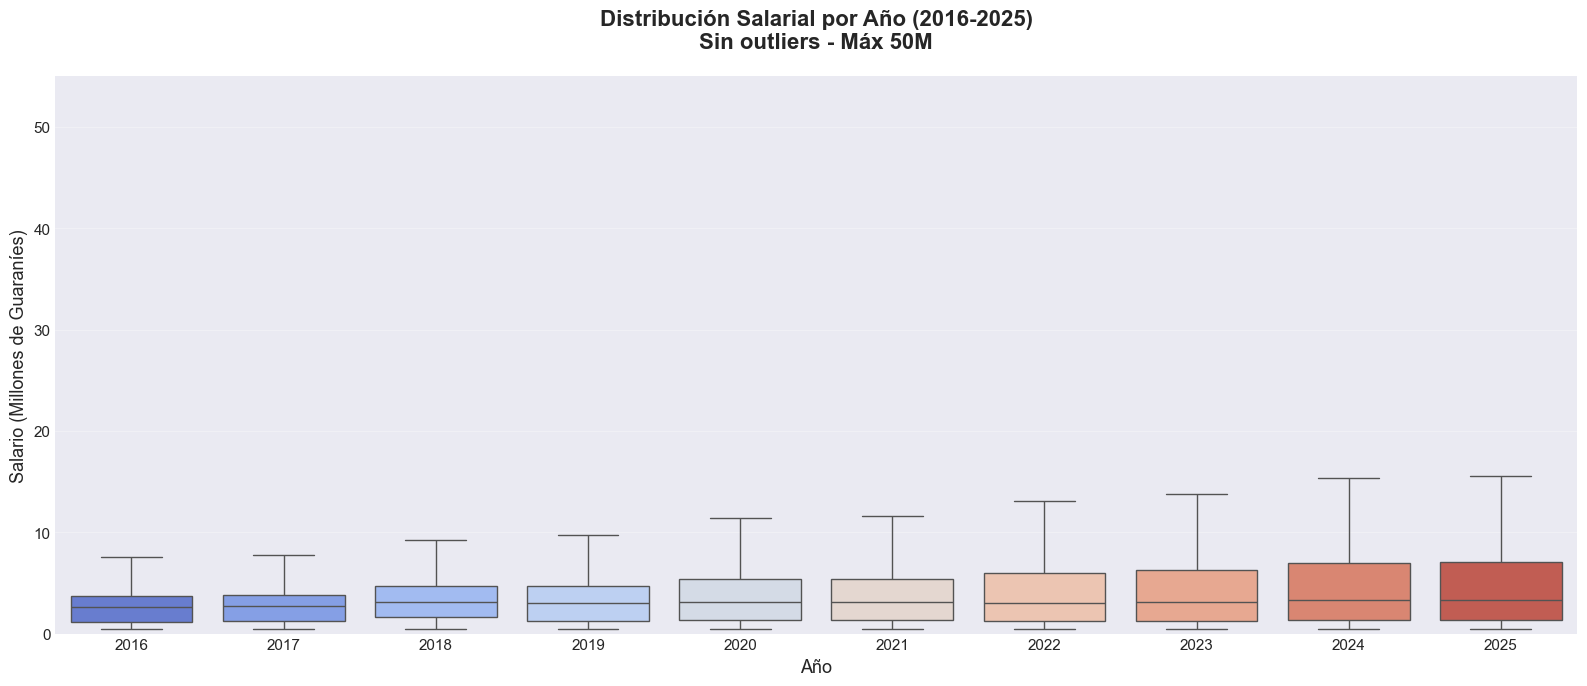

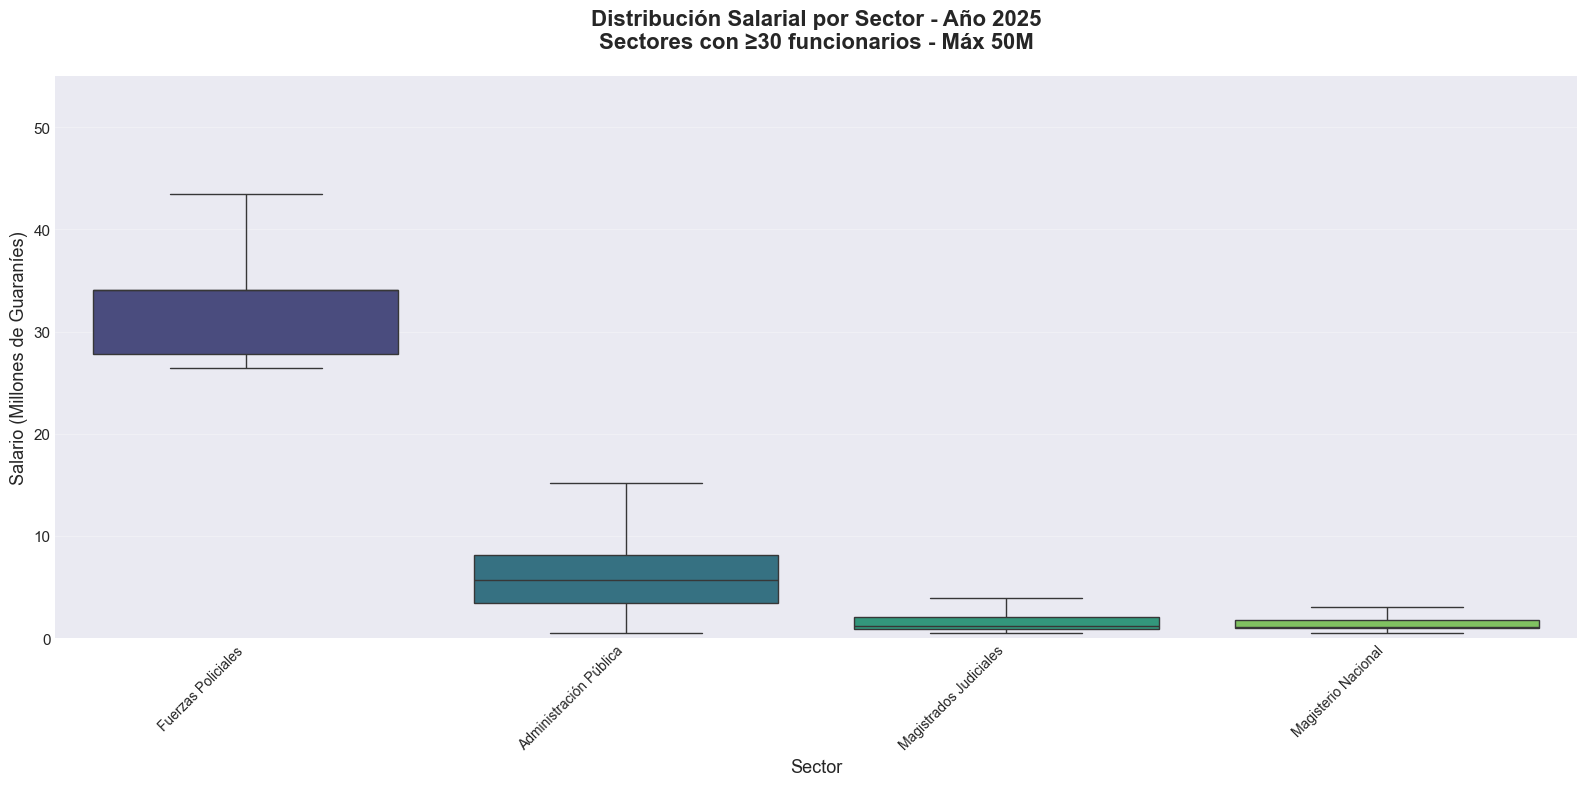

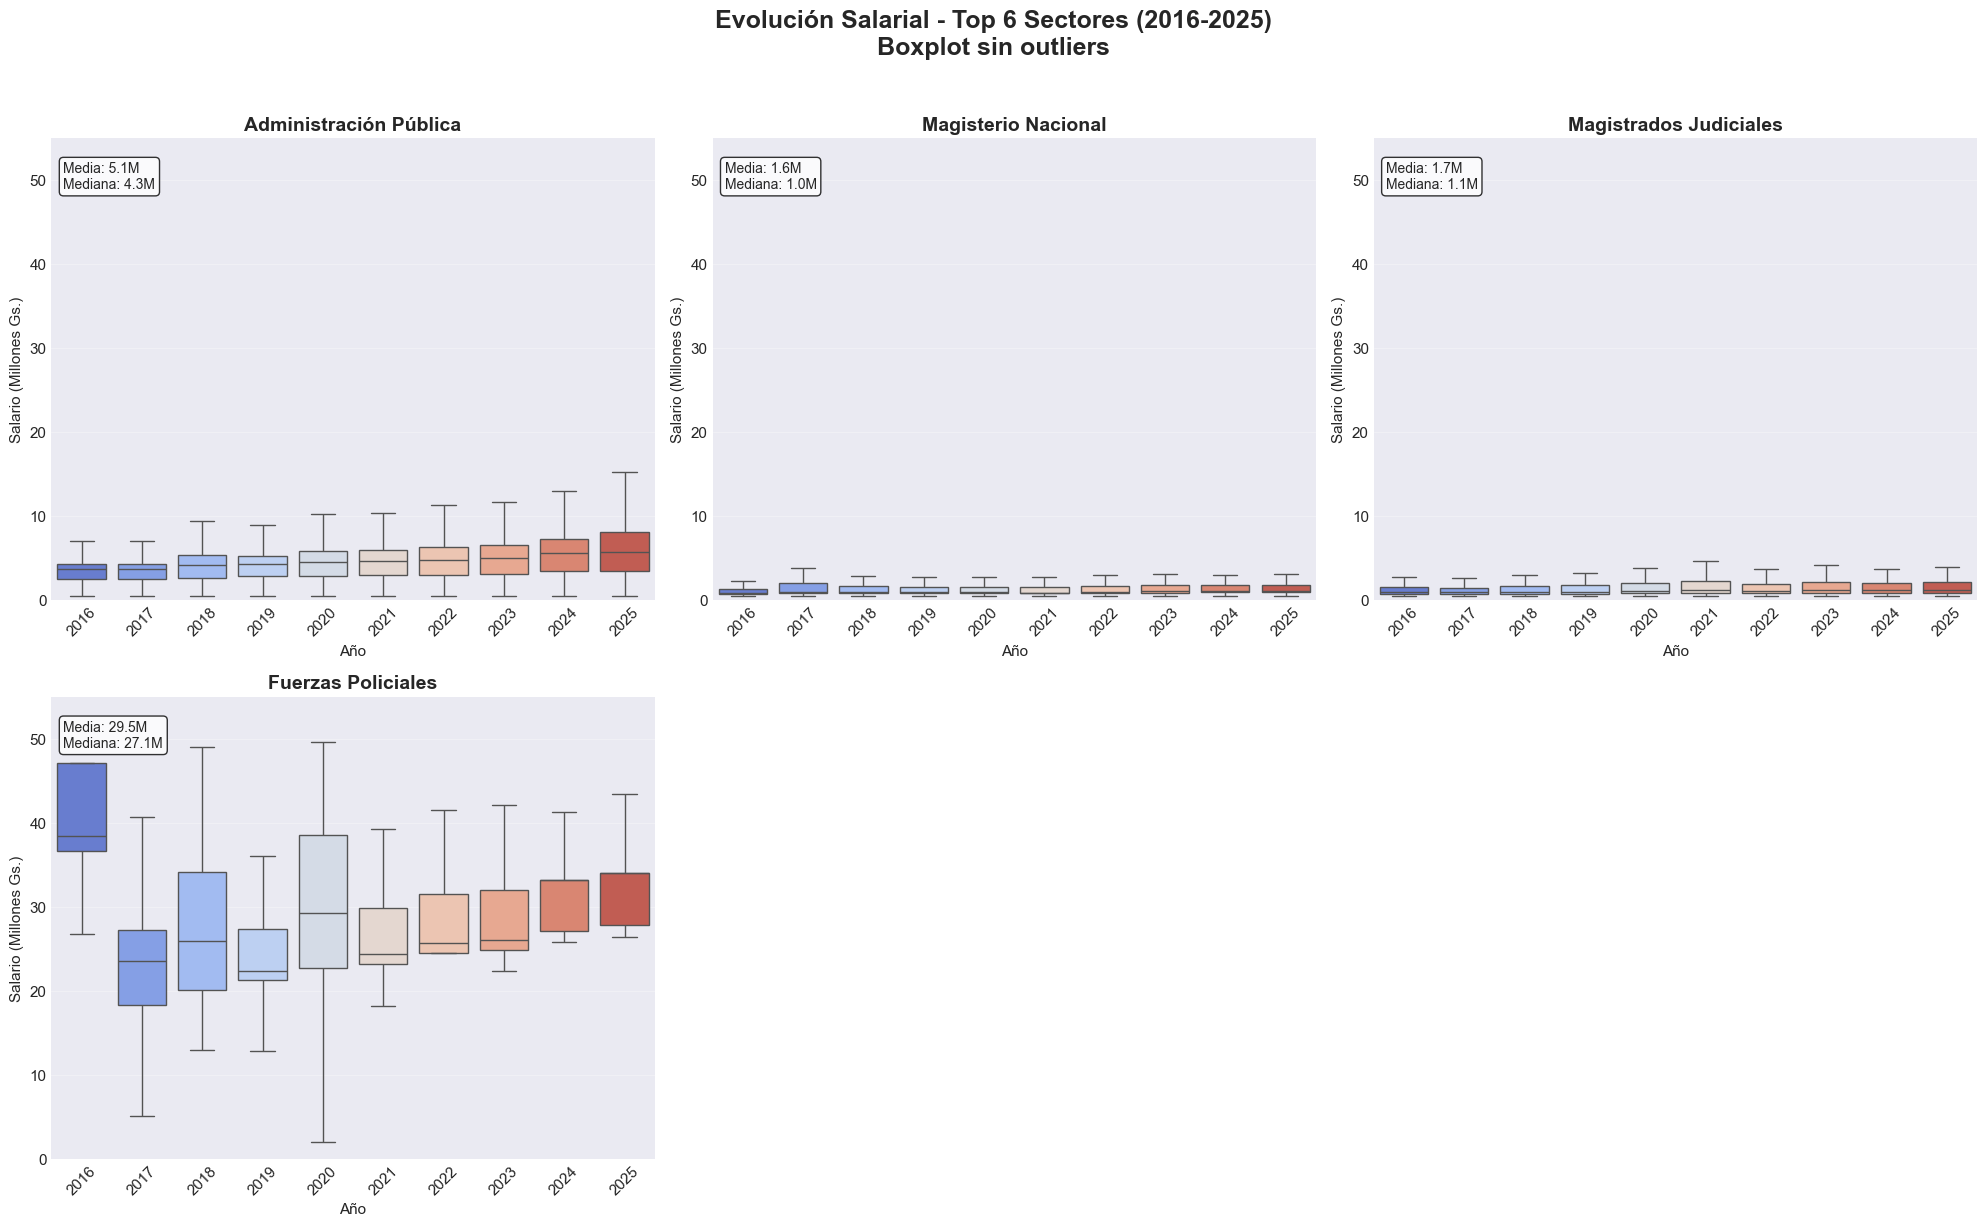

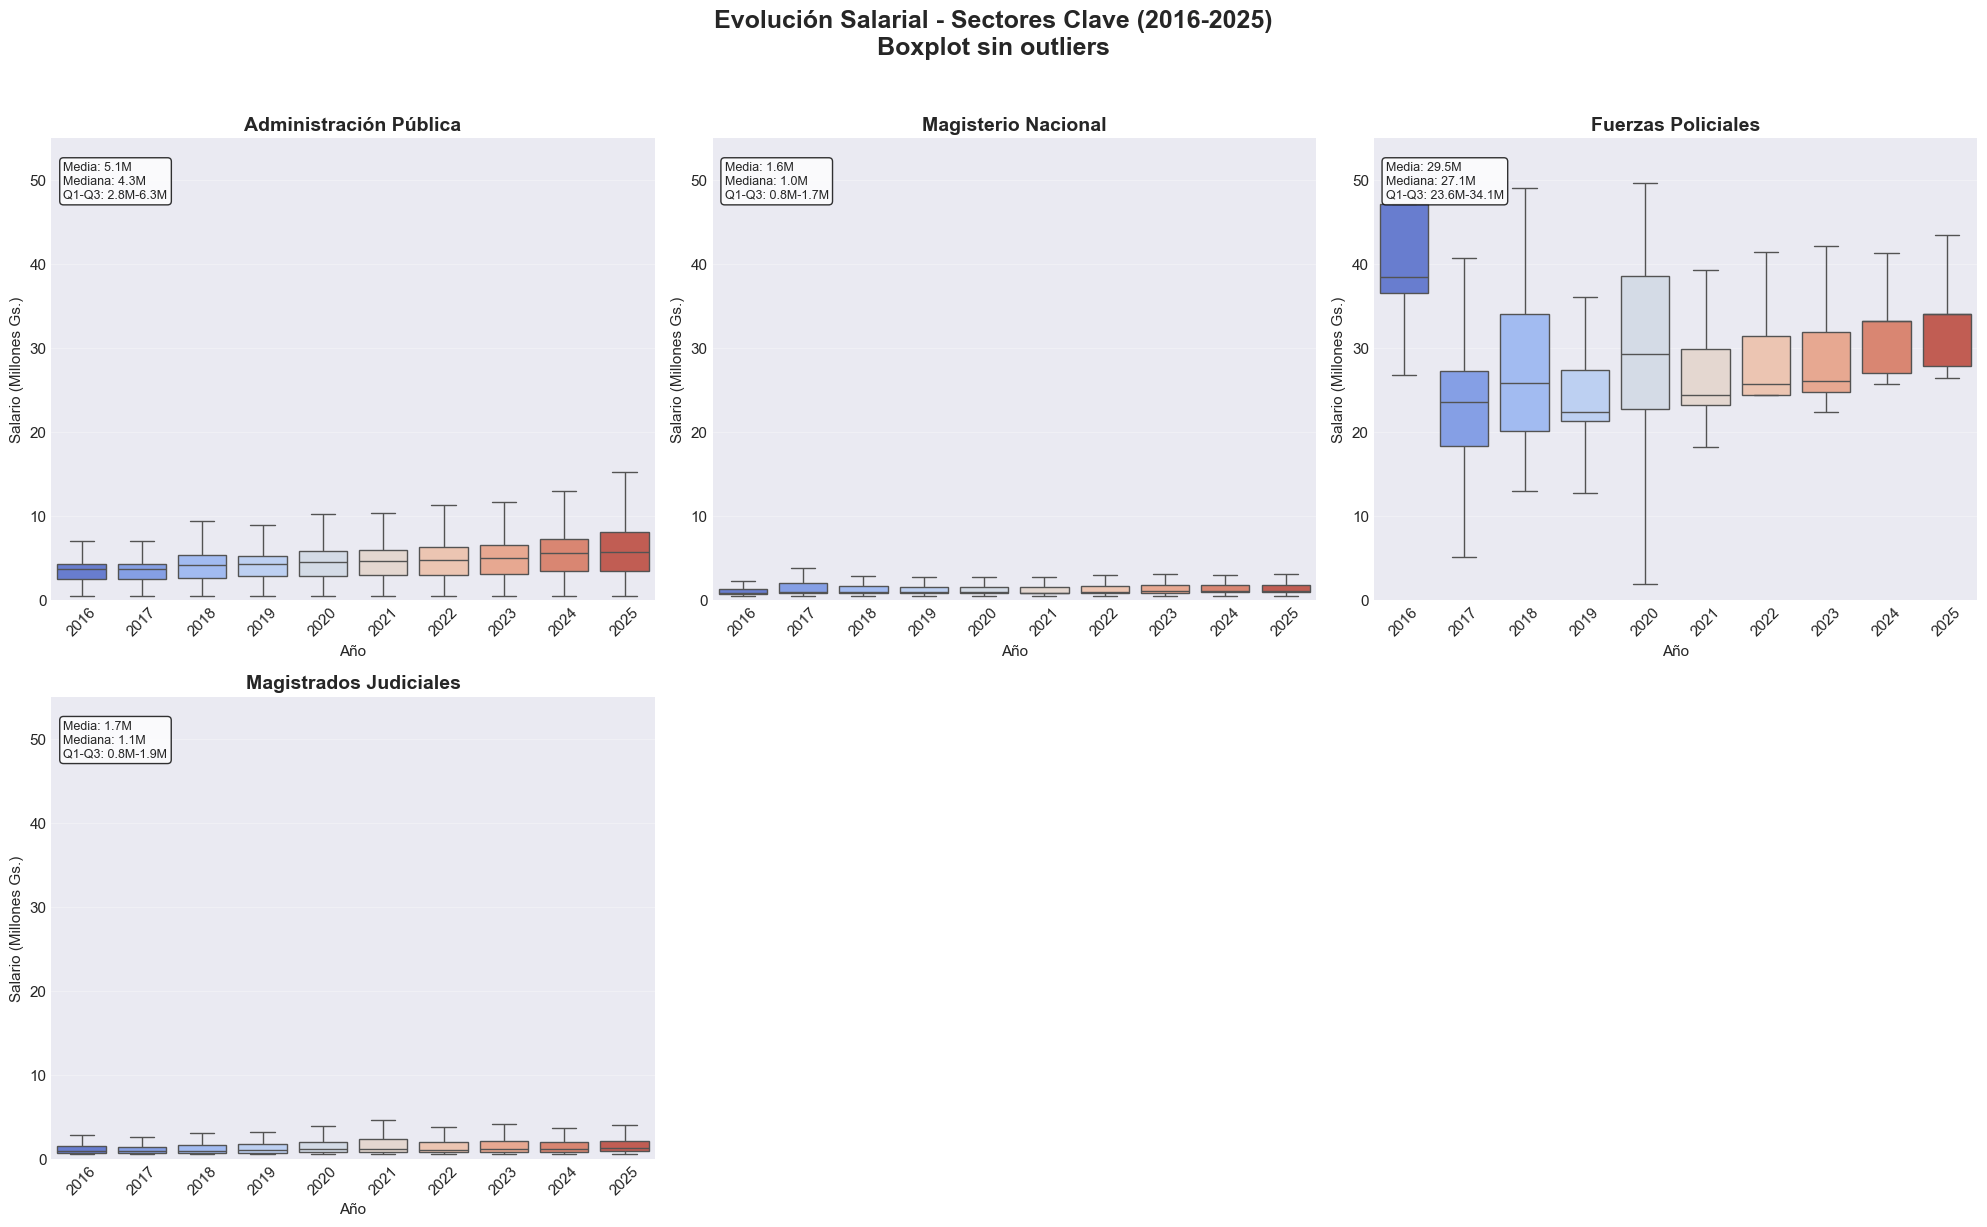

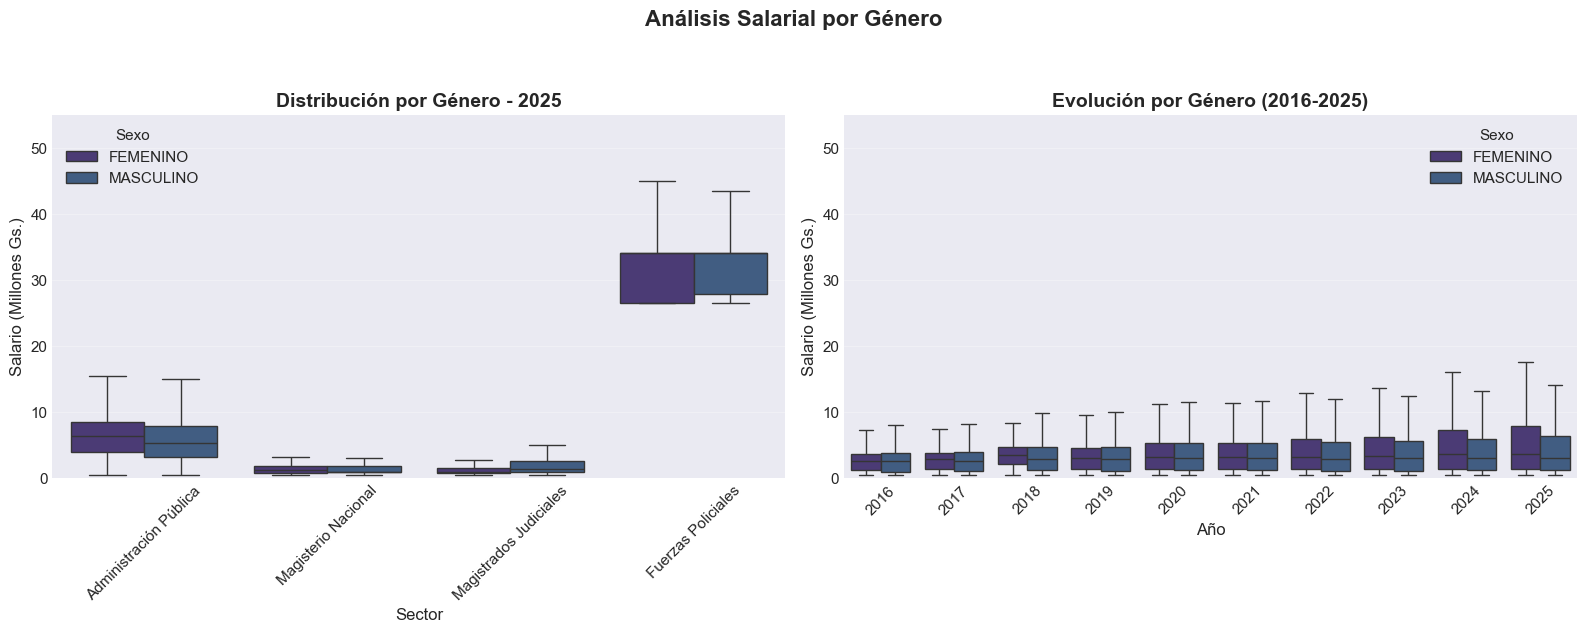


ESTADÍSTICAS DESCRIPTIVAS (SIN OUTLIERS)

📊 SALARIO PROMEDIO POR AÑO:
   2016: 3.07M (n=335,487)
   2017: 3.18M (n=338,412)
   2018: 3.82M (n=312,409)
   2019: 3.61M (n=351,797)
   2020: 3.82M (n=345,573)
   2021: 3.83M (n=347,224)
   2022: 3.93M (n=351,505)
   2023: 4.07M (n=366,999)
   2024: 4.35M (n=379,856)
   2025: 4.81M (n=393,650)

📊 SALARIO PROMEDIO POR SECTOR (2025):
   Fuerzas Policiales: 32.83M | mediana: 34.10M (n=239)
   Administración Pública: 6.87M | mediana: 5.71M (n=234,893)
   Magistrados Judiciales: 1.86M | mediana: 1.22M (n=17,242)
   Magisterio Nacional: 1.70M | mediana: 1.10M (n=141,276)

✅ Visualizaciones completadas


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ===============================
# CONFIGURACIÓN
# ===============================
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (20, 12)
plt.rcParams['font.size'] = 11

# ===============================
# CARGAR DATOS
# ===============================
print("=" * 60)
print("CARGANDO DATOS PARA VISUALIZACIÓN")
print("=" * 60)

ruta_archivo = "D:/ArchivosHDD/GitHub/jubilacionUNA/Datos/Funcionarios2015-2025/funcionarios_2016_2025_para_graficos.csv"

try:
    df = pd.read_csv(ruta_archivo)
    print(f"✅ Archivo cargado: {ruta_archivo}")
    print(f"📊 Registros originales: {len(df):,}")
    print(f"👥 Funcionarios: {df['id_anonimo'].nunique():,}")
except FileNotFoundError:
    print(f"❌ No se encontró el archivo: {ruta_archivo}")
    exit()

# ===============================
# FILTROS PARA ELIMINAR OUTLIERS
# ===============================
print("\n" + "=" * 60)
print("APLICANDO FILTROS PARA ELIMINAR OUTLIERS")
print("=" * 60)

# FILTRO 1: Salario máximo 50 millones
df_filtrado = df[df['devengado'] <= 50_000_000].copy()
print(f"✅ Salarios <= 50M: {len(df_filtrado):,} registros ({len(df_filtrado)/len(df)*100:.1f}%)")
print(f"   Registros eliminados: {len(df) - len(df_filtrado):,}")

# FILTRO 2: Salario mínimo razonable (opcional, evitar ceros o valores muy bajos)
df_filtrado = df_filtrado[df_filtrado['devengado'] >= 500_000].copy()
print(f"✅ Salarios >= 500k: {len(df_filtrado):,} registros")

# Convertir a millones para mejor visualización
df_filtrado['devengado_millones'] = df_filtrado['devengado'] / 1_000_000

print(f"\n📊 Datos finales para gráficos:")
print(f"   Registros: {len(df_filtrado):,}")
print(f"   Funcionarios: {df_filtrado['id_anonimo'].nunique():,}")
print(f"   Años: {sorted(df_filtrado['anho'].unique())}")
print(f"   Sectores: {df_filtrado['sector'].nunique()}")
print(f"   Rango salarial: {df_filtrado['devengado_millones'].min():.1f}M - {df_filtrado['devengado_millones'].max():.1f}M")

# ===============================
# 1. BOXPLOT - POR AÑO (SIN OUTLIERS)
# ===============================
plt.figure(figsize=(16, 7))
sns.boxplot(data=df_filtrado, x='anho', y='devengado_millones', 
            palette='coolwarm', showfliers=False)  # showfliers=False oculta outliers
plt.title('Distribución Salarial por Año (2016-2025)\nSin outliers - Máx 50M', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Año', fontsize=13)
plt.ylabel('Salario (Millones de Guaraníes)', fontsize=13)
plt.ylim(0, 55)  # Fijo para mejor comparación
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ===============================
# 2. BOXPLOT - POR SECTOR (ÚLTIMO AÑO)
# ===============================
ultimo_anio = df_filtrado['anho'].max()
df_ultimo = df_filtrado[df_filtrado['anho'] == ultimo_anio].copy()

# Sectores con al menos 30 funcionarios
sectores_validos = df_ultimo['sector'].value_counts()
sectores_validos = sectores_validos[sectores_validos >= 30].index.tolist()
df_comparativo = df_ultimo[df_ultimo['sector'].isin(sectores_validos)].copy()

# Ordenar por mediana
orden_sectores = df_comparativo.groupby('sector')['devengado_millones'].median().sort_values(ascending=False).index

plt.figure(figsize=(16, 8))
sns.boxplot(data=df_comparativo, x='sector', y='devengado_millones', 
            order=orden_sectores, palette='viridis', showfliers=False)
plt.title(f'Distribución Salarial por Sector - Año {ultimo_anio}\nSectores con ≥30 funcionarios - Máx 50M', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Sector', fontsize=13)
plt.ylabel('Salario (Millones de Guaraníes)', fontsize=13)
plt.ylim(0, 55)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ===============================
# 3. BOXPLOT - TOP 6 SECTORES (EVOLUCIÓN)
# ===============================


# Top 6 sectores con más funcionarios en todo el período
top_sectores = df_filtrado['sector'].value_counts().head(6).index.tolist()
df_top = df_filtrado[df_filtrado['sector'].isin(top_sectores)].copy()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, sector in enumerate(top_sectores):
    ax = axes[i]
    datos_sector = df_top[df_top['sector'] == sector]
    
    sns.boxplot(data=datos_sector, x='anho', y='devengado_millones', 
                ax=ax, palette='coolwarm', showfliers=False)
    
    ax.set_title(f'{sector}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Año', fontsize=11)
    ax.set_ylabel('Salario (Millones Gs.)', fontsize=11)
    ax.set_ylim(0, 55)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Estadísticas
    media = datos_sector['devengado_millones'].mean()
    mediana = datos_sector['devengado_millones'].median()
    ax.text(0.02, 0.95, f'Media: {media:.1f}M\nMediana: {mediana:.1f}M', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Eliminar subplots vacíos
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Evolución Salarial - Top 6 Sectores (2016-2025)\nBoxplot sin outliers', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ===============================
# 4. BOXPLOT - SECTORES CLAVE ESPECÍFICOS
# ===============================

sectores_clave = [
    'Administración Pública',
    'Docentes Universitarios',
    'Magisterio Nacional',
    'Fuerzas Policiales',
    'Fuerzas Armadas',
    'Magistrados Judiciales'
]

# Filtrar solo sectores que existen
sectores_clave = [s for s in sectores_clave if s in df_filtrado['sector'].unique()]
df_clave = df_filtrado[df_filtrado['sector'].isin(sectores_clave)].copy()

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, sector in enumerate(sectores_clave):
    ax = axes[i]
    datos_sector = df_clave[df_clave['sector'] == sector]
    
    sns.boxplot(data=datos_sector, x='anho', y='devengado_millones', 
                ax=ax, palette='coolwarm', showfliers=False)
    
    ax.set_title(f'{sector}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Año', fontsize=11)
    ax.set_ylabel('Salario (Millones Gs.)', fontsize=11)
    ax.set_ylim(0, 55)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Estadísticas
    media = datos_sector['devengado_millones'].mean()
    mediana = datos_sector['devengado_millones'].median()
    q1 = datos_sector['devengado_millones'].quantile(0.25)
    q3 = datos_sector['devengado_millones'].quantile(0.75)
    ax.text(0.02, 0.95, f'Media: {media:.1f}M\nMediana: {mediana:.1f}M\nQ1-Q3: {q1:.1f}M-{q3:.1f}M', 
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Eliminar subplots vacíos
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Evolución Salarial - Sectores Clave (2016-2025)\nBoxplot sin outliers', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ===============================
# 5. COMPARATIVO POR GÉNERO (OPCIONAL)
# ===============================
if 'sexo' in df_filtrado.columns:
    
    df_genero = df_ultimo[df_ultimo['sexo'].isin(['MASCULINO', 'FEMENINO'])].copy()
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Boxplot por género
    sns.boxplot(data=df_genero, x='sector', y='devengado_millones', hue='sexo',
                ax=axes[0], showfliers=False)
    axes[0].set_title(f'Distribución por Género - {ultimo_anio}', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Sector', fontsize=12)
    axes[0].set_ylabel('Salario (Millones Gs.)', fontsize=12)
    axes[0].set_ylim(0, 55)
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(title='Sexo')
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Boxplot evolución por género (todos los años)
    df_genero_total = df_filtrado[df_filtrado['sexo'].isin(['MASCULINO', 'FEMENINO'])].copy()
    sns.boxplot(data=df_genero_total, x='anho', y='devengado_millones', hue='sexo',
                ax=axes[1], showfliers=False)
    axes[1].set_title('Evolución por Género (2016-2025)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Año', fontsize=12)
    axes[1].set_ylabel('Salario (Millones Gs.)', fontsize=12)
    axes[1].set_ylim(0, 55)
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(title='Sexo')
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Análisis Salarial por Género', fontsize=16, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()

# ===============================
# 6. ESTADÍSTICAS RÁPIDAS
# ===============================
print("\n" + "=" * 60)
print("ESTADÍSTICAS DESCRIPTIVAS (SIN OUTLIERS)")
print("=" * 60)

print(f"\n📊 SALARIO PROMEDIO POR AÑO:")
for anio in sorted(df_filtrado['anho'].unique()):
    df_año = df_filtrado[df_filtrado['anho'] == anio]
    print(f"   {anio}: {df_año['devengado_millones'].mean():.2f}M (n={len(df_año):,})")

print(f"\n📊 SALARIO PROMEDIO POR SECTOR ({ultimo_anio}):")
sectores_top = df_ultimo.groupby('sector')['devengado_millones'].agg(['mean', 'median', 'count'])
sectores_top = sectores_top[sectores_top['count'] >= 30].sort_values('mean', ascending=False).head(10)
for sector, row in sectores_top.iterrows():
    print(f"   {sector}: {row['mean']:.2f}M | mediana: {row['median']:.2f}M (n={int(row['count']):,})")

print("\n✅ Visualizaciones completadas")
print("=" * 60)

CARGANDO DATOS PARA VISUALIZACIÓN
✅ Archivo cargado: D:/ArchivosHDD/GitHub/jubilacionUNA/Datos/Funcionarios2015-2025/funcionarios_2016_2025_para_graficos.csv
📊 Registros originales: 4,201,137
👥 Funcionarios: 449,316

APLICANDO FILTROS PARA ELIMINAR OUTLIERS
✅ Salarios <= 50,000,000: 4,200,313 registros (100.0%)

📊 Datos finales: 3,522,912 registros
   Rango salarial: 0.5M - 49.8M


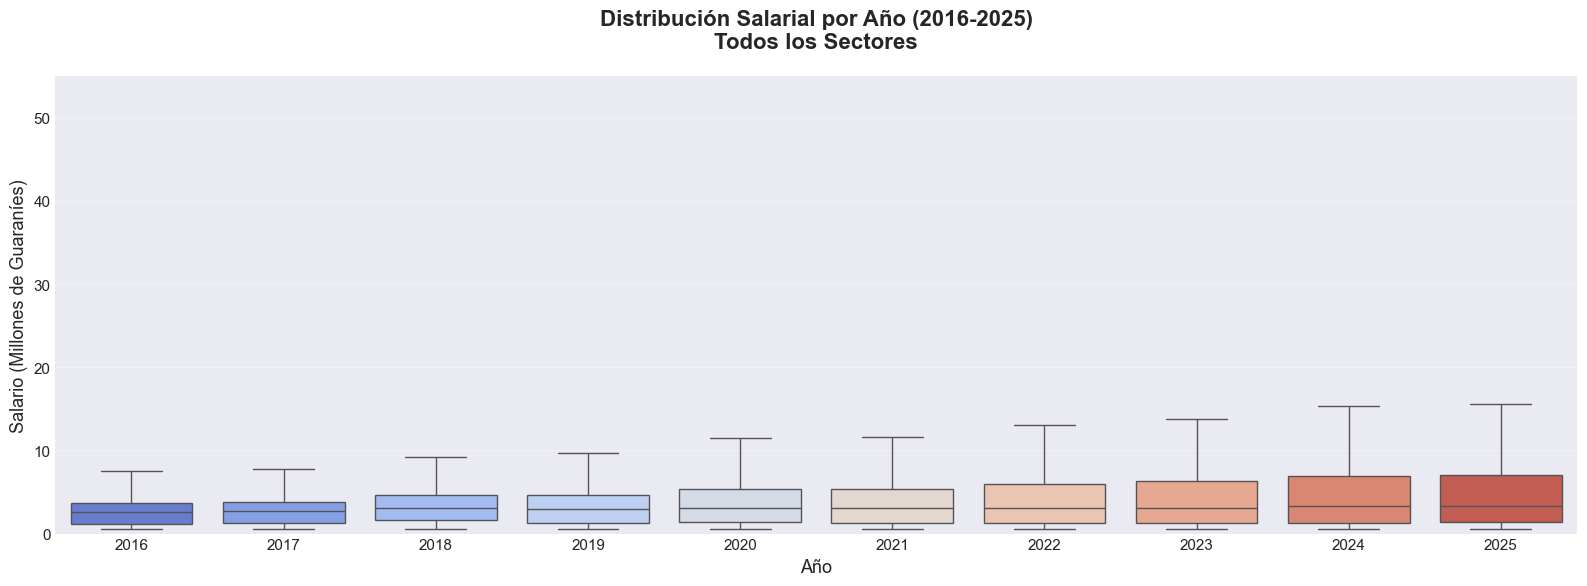

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ===============================
# CONFIGURACIÓN
# ===============================
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (20, 12)
plt.rcParams['font.size'] = 11

# ===============================
# CARGAR DATOS
# ===============================
print("=" * 60)
print("CARGANDO DATOS PARA VISUALIZACIÓN")
print("=" * 60)

ruta_archivo = "D:/ArchivosHDD/GitHub/jubilacionUNA/Datos/Funcionarios2015-2025/funcionarios_2016_2025_para_graficos.csv"

try:
    df = pd.read_csv(ruta_archivo)
    print(f"✅ Archivo cargado: {ruta_archivo}")
    print(f"📊 Registros originales: {len(df):,}")
    print(f"👥 Funcionarios: {df['id_anonimo'].nunique():,}")
except FileNotFoundError:
    print(f"❌ No se encontró el archivo: {ruta_archivo}")
    exit()

# ===============================
# FILTROS PARA ELIMINAR OUTLIERS
# ===============================
print("\n" + "=" * 60)
print("APLICANDO FILTROS PARA ELIMINAR OUTLIERS")
print("=" * 60)

# Salario máximo 50 millones (ajustable)
LIMITE_SALARIO = 50_000_000
df_filtrado = df[df['devengado'] <= LIMITE_SALARIO].copy()
print(f"✅ Salarios <= {LIMITE_SALARIO:,}: {len(df_filtrado):,} registros ({len(df_filtrado)/len(df)*100:.1f}%)")

df_filtrado = df_filtrado[df_filtrado['devengado'] >= 500_000].copy()
df_filtrado['devengado_millones'] = df_filtrado['devengado'] / 1_000_000

print(f"\n📊 Datos finales: {len(df_filtrado):,} registros")
print(f"   Rango salarial: {df_filtrado['devengado_millones'].min():.1f}M - {df_filtrado['devengado_millones'].max():.1f}M")

# ===============================
# 1. BOXPLOT POR AÑO - TODOS LOS SECTORES
# ===============================
plt.figure(figsize=(16, 6))
sns.boxplot(data=df_filtrado, x='anho', y='devengado_millones', 
            palette='coolwarm', showfliers=False)
plt.title('Distribución Salarial por Año (2016-2025)\nTodos los Sectores', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Año', fontsize=13)
plt.ylabel('Salario (Millones de Guaraníes)', fontsize=13)
plt.ylim(0, 55)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()



📊 Sectores clave a graficar: ['Fuerzas Policiales', 'Magistrados Judiciales', 'Administración Pública', 'Magisterio Nacional']


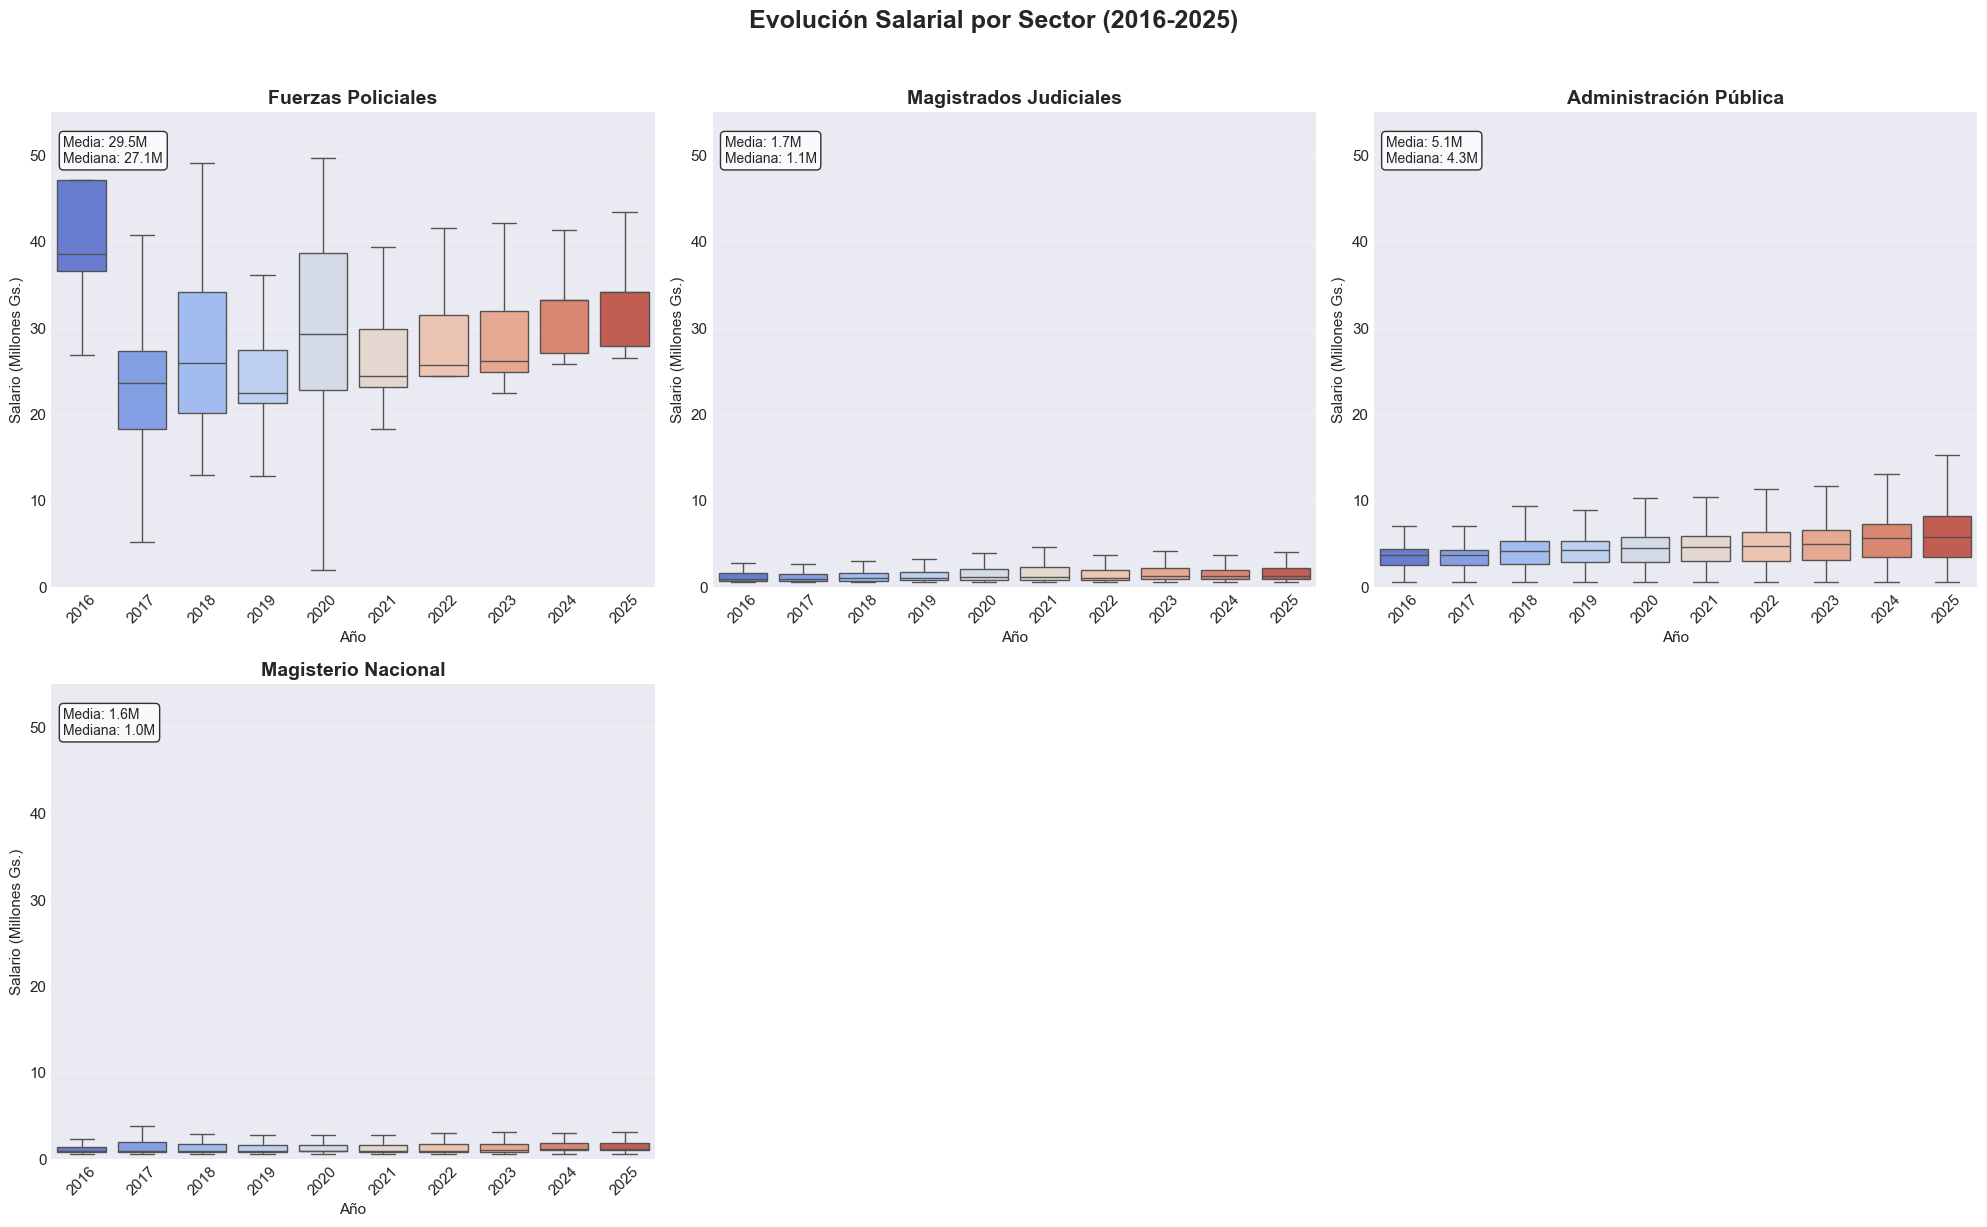


ANÁLISIS DE BRECHA SALARIAL


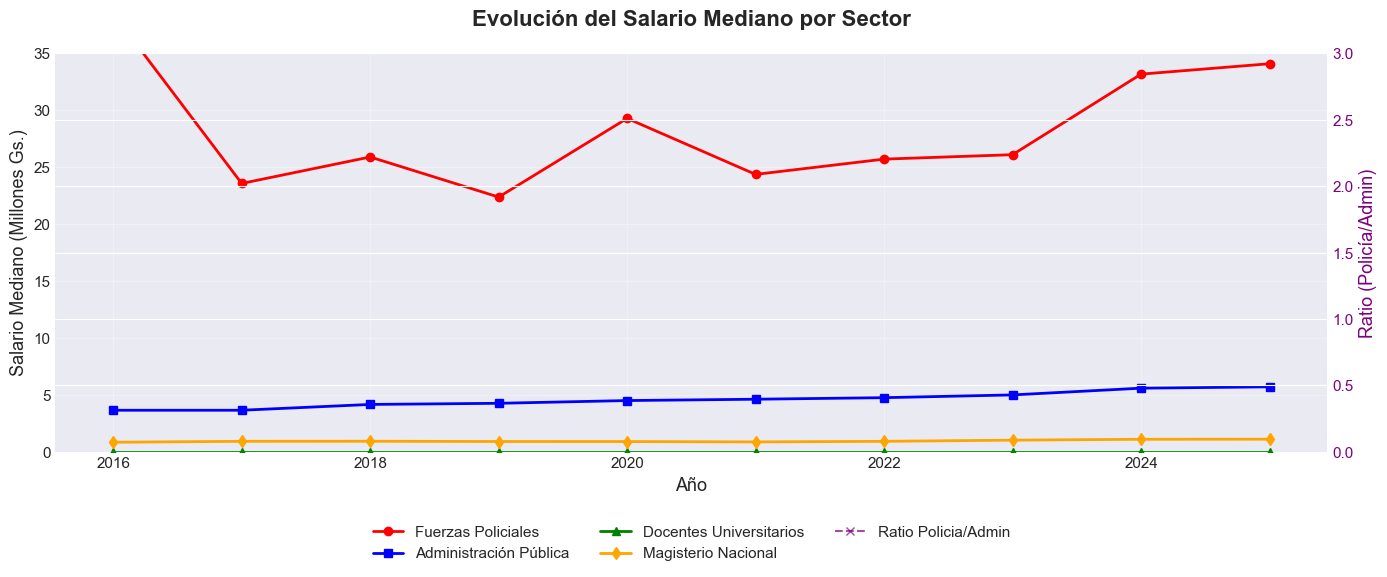


📊 BRECHA SALARIAL POLICÍA VS ADMINISTRACIÓN:
   2016: Policía 38.5M | Admin 3.6M | Diferencia: +34.9M (10.55x)
   2017: Policía 23.6M | Admin 3.6M | Diferencia: +19.9M (6.46x)
   2018: Policía 25.9M | Admin 4.2M | Diferencia: +21.7M (6.23x)
   2019: Policía 22.4M | Admin 4.3M | Diferencia: +18.1M (5.25x)
   2020: Policía 29.3M | Admin 4.5M | Diferencia: +24.8M (6.51x)
   2021: Policía 24.4M | Admin 4.6M | Diferencia: +19.8M (5.28x)
   2022: Policía 25.7M | Admin 4.8M | Diferencia: +21.0M (5.41x)
   2023: Policía 26.1M | Admin 5.0M | Diferencia: +21.1M (5.23x)
   2024: Policía 33.2M | Admin 5.6M | Diferencia: +27.6M (5.94x)
   2025: Policía 34.1M | Admin 5.7M | Diferencia: +28.4M (5.98x)

ANÁLISIS POR CARGO - FUERZAS POLICIALES


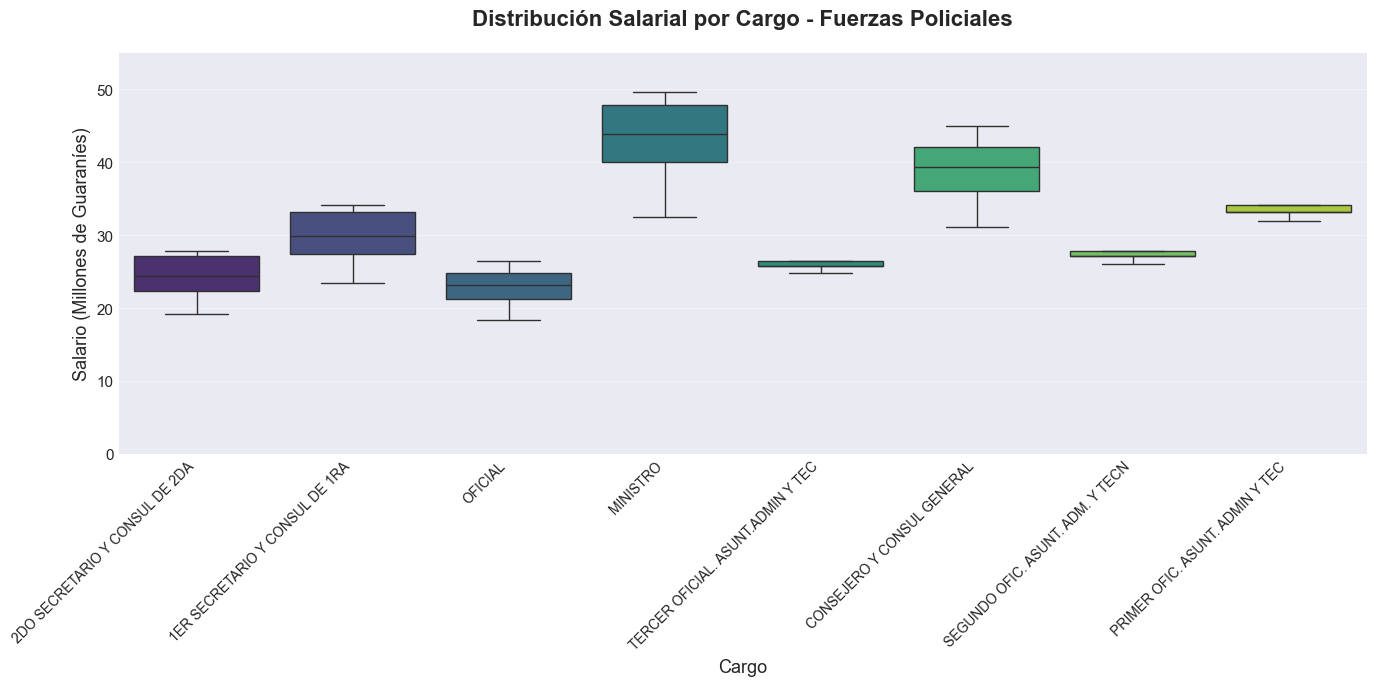


📊 SALARIO POR CARGO - POLICÍA (2025):
   CONSEJERO Y CONSUL GENERAL: 44.9M | mediana: 44.9M (n=30)
   1ER SECRETARIO Y CONSUL DE 1RA: 34.1M | mediana: 34.1M (n=77)
   PRIMER OFIC. ASUNT. ADMIN Y TEC: 34.1M | mediana: 34.1M (n=12)
   2DO SECRETARIO Y CONSUL DE 2DA: 27.8M | mediana: 27.8M (n=36)
   SEGUNDO OFIC. ASUNT. ADM. Y TECN: 27.8M | mediana: 27.8M (n=11)
   OFICIAL: 26.5M | mediana: 26.5M (n=42)
   TERCER OFICIAL. ASUNT.ADMIN Y TEC: 26.5M | mediana: 26.5M (n=13)

✅ ANÁLISIS COMPLETADO


In [9]:
sectores_clave = [
    'Fuerzas Policiales',
    'Fuerzas Armadas', 
    'Magistrados Judiciales',
    'Docentes Universitarios',
    'Administración Pública',
    'Magisterio Nacional'
]

# Verificar qué sectores existen realmente
sectores_clave = [s for s in sectores_clave if s in df_filtrado['sector'].unique()]
print(f"\n📊 Sectores clave a graficar: {sectores_clave}")

n_sectores = len(sectores_clave)
n_cols = 3
n_rows = (n_sectores + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes.flatten()

for i, sector in enumerate(sectores_clave):
    ax = axes[i]
    datos_sector = df_filtrado[df_filtrado['sector'] == sector]
    
    sns.boxplot(data=datos_sector, x='anho', y='devengado_millones', 
                ax=ax, palette='coolwarm', showfliers=False)
    
    ax.set_title(f'{sector}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Año', fontsize=11)
    ax.set_ylabel('Salario (Millones Gs.)', fontsize=11)
    ax.set_ylim(0, 55)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Estadísticas
    media = datos_sector['devengado_millones'].mean()
    mediana = datos_sector['devengado_millones'].median()
    ax.text(0.02, 0.95, f'Media: {media:.1f}M\nMediana: {mediana:.1f}M', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Ocultar ejes vacíos
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Evolución Salarial por Sector (2016-2025)', 
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ===============================
# 5. ANÁLISIS DE BRECHA SALARIAL (Policiales vs Admin)
# ===============================
print("\n" + "=" * 60)
print("ANÁLISIS DE BRECHA SALARIAL")
print("=" * 60)

# Calcular brecha por año
brechas = []
for anio in sorted(df_filtrado['anho'].unique()):
    df_año = df_filtrado[df_filtrado['anho'] == anio]
    
    salario_policia = df_año[df_año['sector'] == 'Fuerzas Policiales']['devengado_millones'].median()
    salario_admin = df_año[df_año['sector'] == 'Administración Pública']['devengado_millones'].median()
    salario_docentes = df_año[df_año['sector'] == 'Docentes Universitarios']['devengado_millones'].median() if 'Docentes Universitarios' in df_año['sector'].unique() else 0
    salario_magisterio = df_año[df_año['sector'] == 'Magisterio Nacional']['devengado_millones'].median()
    
    if salario_admin > 0:
        brechas.append({
            'anio': anio,
            'policia': salario_policia,
            'admin': salario_admin,
            'docentes': salario_docentes,
            'magisterio': salario_magisterio,
            'brecha_policia_vs_admin': salario_policia - salario_admin,
            'ratio_policia_vs_admin': salario_policia / salario_admin
        })

df_brechas = pd.DataFrame(brechas)

# Gráfico de brecha
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(df_brechas['anio'], df_brechas['policia'], 'o-', linewidth=2, label='Fuerzas Policiales', color='red')
ax1.plot(df_brechas['anio'], df_brechas['admin'], 's-', linewidth=2, label='Administración Pública', color='blue')
ax1.plot(df_brechas['anio'], df_brechas['docentes'], '^-', linewidth=2, label='Docentes Universitarios', color='green')
ax1.plot(df_brechas['anio'], df_brechas['magisterio'], 'd-', linewidth=2, label='Magisterio Nacional', color='orange')

ax1.set_xlabel('Año', fontsize=13)
ax1.set_ylabel('Salario Mediano (Millones Gs.)', fontsize=13)
ax1.set_title('Evolución del Salario Mediano por Sector', fontsize=16, fontweight='bold', pad=20)
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 35)

# Agregar segunda escala para el ratio
ax2 = ax1.twinx()
ax2.plot(df_brechas['anio'], df_brechas['ratio_policia_vs_admin'], 'x--', linewidth=1.5, 
         label='Ratio Policia/Admin', color='purple', alpha=0.7)
ax2.set_ylabel('Ratio (Policía/Admin)', fontsize=13, color='purple')
ax2.tick_params(axis='y', labelcolor='purple')
ax2.set_ylim(0, 3)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

plt.tight_layout()
plt.show()

# Mostrar tabla de brechas
print(f"\n📊 BRECHA SALARIAL POLICÍA VS ADMINISTRACIÓN:")
for _, row in df_brechas.iterrows():
    print(f"   {int(row['anio'])}: Policía {row['policia']:.1f}M | Admin {row['admin']:.1f}M | "
          f"Diferencia: +{row['brecha_policia_vs_admin']:.1f}M ({row['ratio_policia_vs_admin']:.2f}x)")

# ===============================
# 6. DISTRIBUCIÓN POR CARGO (Policiales)
# ===============================
if 'cargo' in df_filtrado.columns:
    print("\n" + "=" * 60)
    print("ANÁLISIS POR CARGO - FUERZAS POLICIALES")
    print("=" * 60)
    
    df_policia = df_filtrado[df_filtrado['sector'] == 'Fuerzas Policiales'].copy()
    
    # Top cargos en policía
    top_cargos = df_policia['cargo'].value_counts().head(8).index.tolist()
    df_cargos = df_policia[df_policia['cargo'].isin(top_cargos)]
    
    plt.figure(figsize=(14, 7))
    sns.boxplot(data=df_cargos, x='cargo', y='devengado_millones', 
                palette='viridis', showfliers=False)
    plt.title('Distribución Salarial por Cargo - Fuerzas Policiales', 
              fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Cargo', fontsize=13)
    plt.ylabel('Salario (Millones de Guaraníes)', fontsize=13)
    plt.ylim(0, 55)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    # Estadísticas por cargo
    print(f"\n📊 SALARIO POR CARGO - POLICÍA ({ultimo_anio}):")
    df_policia_ultimo = df_policia[df_policia['anho'] == ultimo_anio]
    cargo_stats = df_policia_ultimo.groupby('cargo')['devengado_millones'].agg(['mean', 'median', 'count'])
    cargo_stats = cargo_stats[cargo_stats['count'] >= 10].sort_values('median', ascending=False).head(10)
    
    for cargo, row in cargo_stats.iterrows():
        print(f"   {cargo}: {row['mean']:.1f}M | mediana: {row['median']:.1f}M (n={int(row['count']):,})")

print("\n" + "=" * 60)
print("✅ ANÁLISIS COMPLETADO")
print("=" * 60)